In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


# ---- ENVIRONMENT (same as yours) ----
class TrafficGridEnv:
    def __init__(self, size=8):
        self.size = size
        self._agent_location = np.array([0, 0], dtype=np.int32)
        self._target_location = np.array([size - 1, size - 1], dtype=np.int32)
        self.traffic_map = np.zeros((size, size), dtype=np.float32)
        self._action_to_direction = {
            0: np.array([0, 1]),   # right
            1: np.array([-1, 0]),  # up
            2: np.array([0, -1]),  # left
            3: np.array([1, 0]),   # down
        }

    def generate_traffic(self, num_cells=6):
        self.traffic_map = np.zeros((self.size, self.size), dtype=np.float32)
        placed = 0
        while placed < num_cells:
            r, c = random.randint(0, self.size - 1), random.randint(0, self.size - 1)
            if (r, c) != (0, 0) and (r, c) != (self.size - 1, self.size - 1) and self.traffic_map[r, c] == 0:
                self.traffic_map[r, c] = random.uniform(0.6, 1.0)
                placed += 1

    def reset(self):
        self._agent_location = np.array([0, 0], dtype=np.int32)
        self.generate_traffic()
        return self._get_state()

    def _get_state(self):
        # 2-channel grid: traffic map + agent position
        state = np.zeros((2, self.size, self.size), dtype=np.float32)
        state[0] = self.traffic_map
        x, y = self._agent_location
        state[1, x, y] = 1.0
        return state

    def step(self, action):
        direction = self._action_to_direction[action]
        new_loc = np.clip(self._agent_location + direction, 0, self.size - 1)
        hit_wall = np.array_equal(new_loc, self._agent_location)
        self._agent_location = new_loc
        terminated = np.array_equal(self._agent_location, self._target_location)

        x, y = self._agent_location
        traffic = self.traffic_map[x, y]

        if terminated:
            reward = 50
        elif hit_wall:
            reward = -2
        elif traffic > 0.5:
            reward = -10
        else:
            reward = -1

        return self._get_state(), reward, terminated


# ---- DQN NETWORK ----
class DQN(nn.Module):
    def __init__(self, size=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2 * size * size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        return self.net(x)


# ---- REPLAY BUFFER ----
class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions), np.array(rewards, dtype=np.float32),
                np.array(next_states), np.array(dones, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)


# ---- TRAINING ----
env = TrafficGridEnv(size=8)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

policy_net = DQN(size=8).to(device)
target_net = DQN(size=8).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.Adam(policy_net.parameters(), lr=0.001)
replay = ReplayBuffer(50000)

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995
batch_size = 64
gamma = 0.95
target_update = 500  # copy policy -> target every N episodes

reached = 0
rewards_log = []

for episode in range(10000):
    state = env.reset()
    total_reward = 0
    terminated = False

    for step in range(200):
        # Epsilon-greedy action
        if random.random() < epsilon:
            action = random.randint(0, 3)
        else:
            with torch.no_grad():
                s = torch.FloatTensor(state).unsqueeze(0).to(device)
                action = policy_net(s).argmax(dim=1).item()

        next_state, reward, terminated = env.step(action)
        replay.push(state, action, reward, next_state, terminated)
        state = next_state
        total_reward += reward

        # Train from replay buffer
        if len(replay) >= batch_size:
            states, actions, rewards, next_states, dones = replay.sample(batch_size)

            states_t = torch.FloatTensor(states).to(device)
            actions_t = torch.LongTensor(actions).to(device)
            rewards_t = torch.FloatTensor(rewards).to(device)
            next_states_t = torch.FloatTensor(next_states).to(device)
            dones_t = torch.FloatTensor(dones).to(device)

            # Current Q values
            q_values = policy_net(states_t).gather(1, actions_t.unsqueeze(1)).squeeze(1)

            # Target Q values (from frozen target network)
            with torch.no_grad():
                next_q = target_net(next_states_t).max(dim=1)[0]
                target_q = rewards_t + gamma * next_q * (1 - dones_t)

            loss = nn.MSELoss()(q_values, target_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if terminated:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards_log.append(total_reward)

    if terminated:
        reached += 1

    # Sync target network
    if (episode + 1) % target_update == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if (episode + 1) % 1000 == 0:
        avg_r = np.mean(rewards_log[-1000:])
        print(f"Episode {episode+1}/10000 | epsilon: {epsilon:.3f} | reached: {reached}/1000 | avg_reward: {avg_r:.1f}")
        reached = 0

print("Training complete")


Episode 1000/10000 | epsilon: 0.606 | reached: 538/1000 | avg_reward: -218.3
Episode 2000/10000 | epsilon: 0.368 | reached: 800/1000 | avg_reward: -104.0
Episode 3000/10000 | epsilon: 0.223 | reached: 877/1000 | avg_reward: -60.6
Episode 4000/10000 | epsilon: 0.135 | reached: 984/1000 | avg_reward: -3.6
Episode 5000/10000 | epsilon: 0.082 | reached: 979/1000 | avg_reward: 3.9
Episode 6000/10000 | epsilon: 0.050 | reached: 999/1000 | avg_reward: 25.1
Episode 7000/10000 | epsilon: 0.050 | reached: 999/1000 | avg_reward: 29.9
Episode 8000/10000 | epsilon: 0.050 | reached: 1000/1000 | avg_reward: 33.2
Episode 9000/10000 | epsilon: 0.050 | reached: 1000/1000 | avg_reward: 33.5
Episode 10000/10000 | epsilon: 0.050 | reached: 1000/1000 | avg_reward: 34.0
Training complete


Test 1: Reached target in 14 steps
Test 2: Reached target in 14 steps
Test 3: Reached target in 14 steps
Test 4: Reached target in 14 steps
Test 5: Reached target in 14 steps
Test 6: Reached target in 14 steps


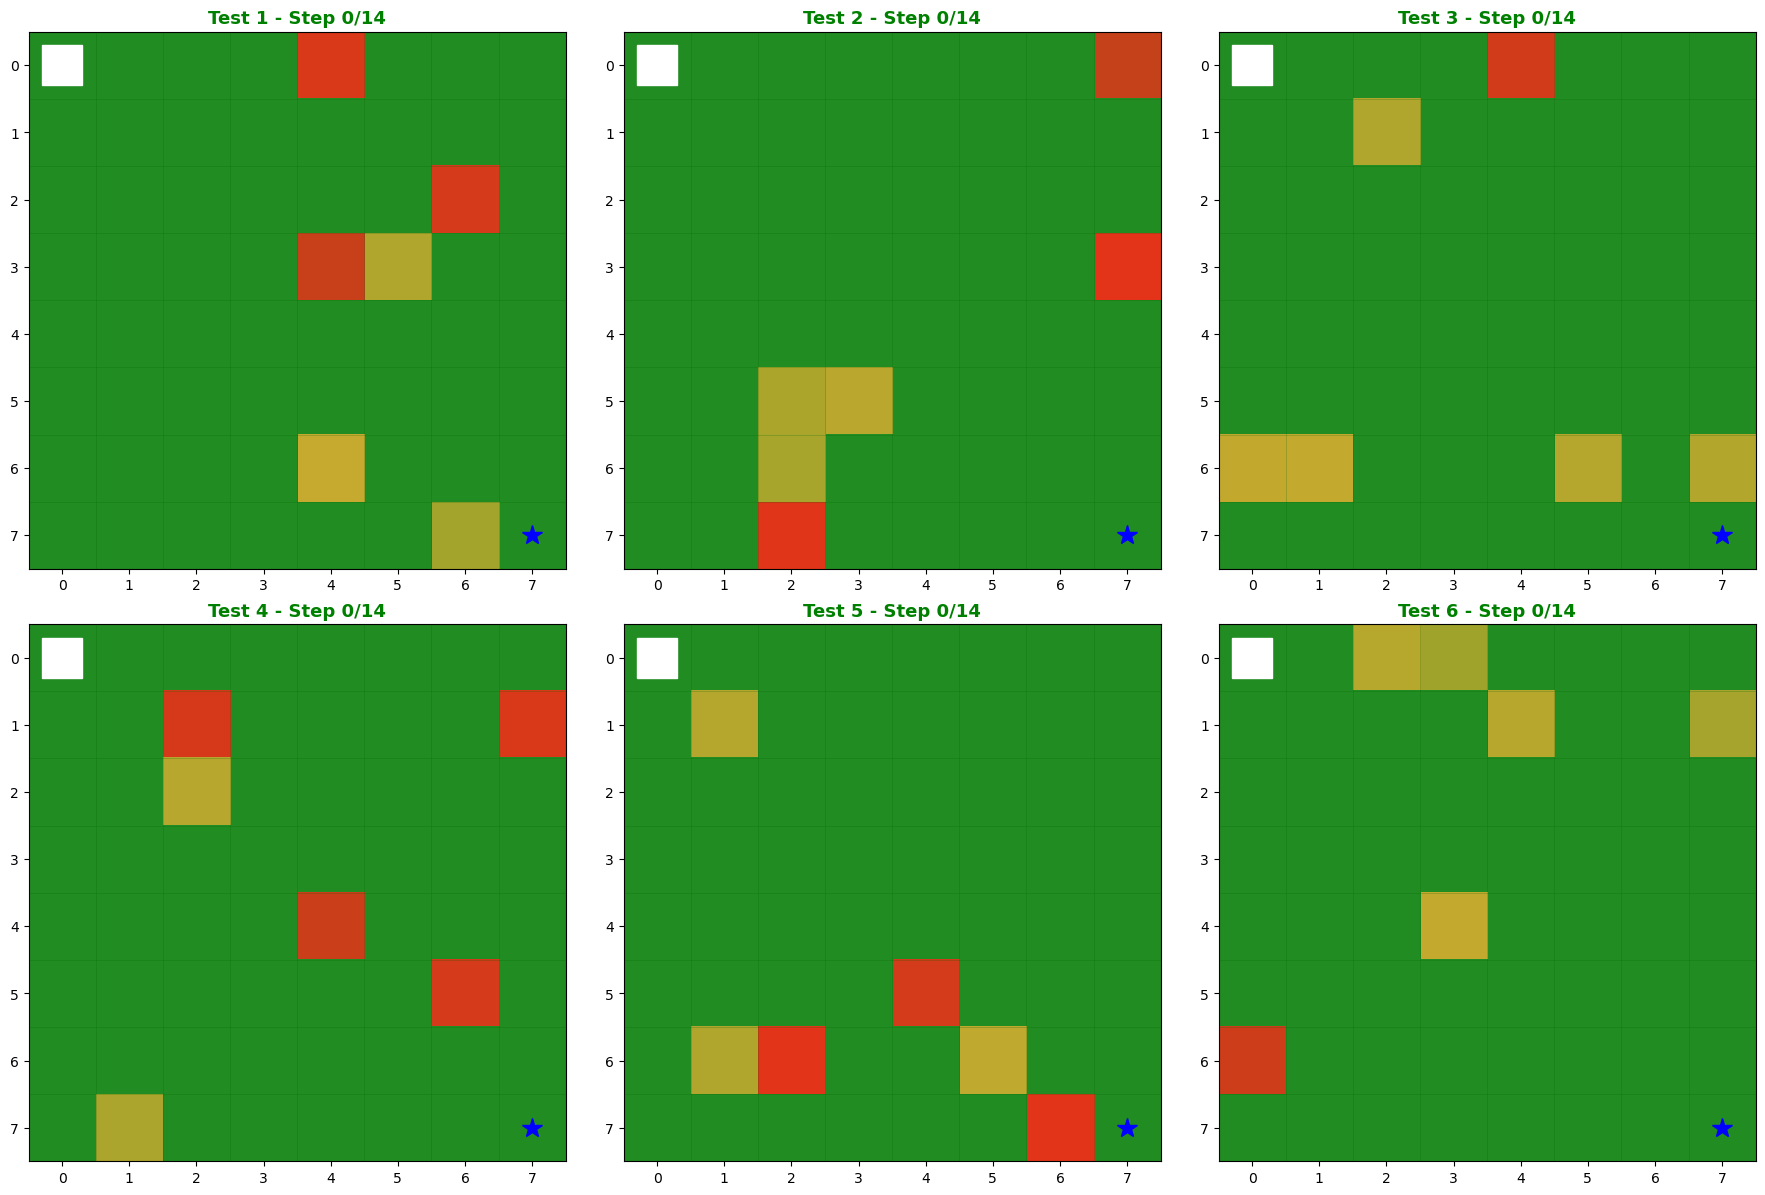

In [5]:
# ---- TEST & ANIMATE 6 TESTS ----
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
anims = []

for test_idx in range(6):
    state = env.reset()
    path = [env._agent_location.copy()]
    terminated = False

    for s in range(200):
        with torch.no_grad():
            s_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            action = policy_net(s_t).argmax(dim=1).item()
        state, reward, terminated = env.step(action)
        path.append(env._agent_location.copy())
        if terminated:
            break

    steps = len(path) - 1
    status = f"Reached target in {steps} steps" if terminated else f"Failed in {steps} steps"
    print(f"Test {test_idx+1}: {status}")
    anims.append((path, env.traffic_map.copy(), test_idx, steps, terminated))

plt.close(fig)

# Animated version
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 12))
axes2 = axes2.flatten()
max_frames = max(len(a[0]) for a in anims)

def update(frame):
    for i, (path, traffic, tidx, steps, reached) in enumerate(anims):
        ax = axes2[i]
        ax.clear()
        size = env.size
        display = np.ones((size, size, 3)) * np.array([0.13, 0.55, 0.13])
        for r in range(size):
            for c in range(size):
                t = traffic[r, c]
                if t > 0.5:
                    base = np.array([0.13, 0.55, 0.13])
                    red = np.array([0.9, 0.2, 0.1])
                    orange = np.array([0.95, 0.7, 0.2])
                    color = orange if t < 0.8 else red
                    display[r, c] = base * (1 - t) + color * t
        ax.imshow(display, origin='upper')
        for j in range(size + 1):
            ax.axhline(j - 0.5, color='darkgreen', linewidth=0.5, alpha=0.3)
            ax.axvline(j - 0.5, color='darkgreen', linewidth=0.5, alpha=0.3)
        goal = size - 1
        ax.plot(goal, goal, marker='*', color='blue', markersize=15, zorder=5)
        idx = min(frame, len(path) - 1)
        if idx > 0:
            xs = [p[1] for p in path[:idx+1]]
            ys = [p[0] for p in path[:idx+1]]
            ax.plot(xs, ys, 'w-', linewidth=1.5, alpha=0.4, zorder=3)
        px, py = path[idx]
        ax.add_patch(plt.Rectangle((py - 0.3, px - 0.3), 0.6, 0.6,
                                    color='white', zorder=4))
        ax.set_xlim(-0.5, size - 0.5)
        ax.set_ylim(size - 0.5, -0.5)
        ax.set_xticks(range(size))
        ax.set_yticks(range(size))
        result = "REACHED" if reached and frame >= len(path)-1 else f"Step {min(frame, len(path)-1)}/{steps}"
        color_title = 'green' if reached else 'red'
        ax.set_title(f"Test {tidx+1} - {result}", color=color_title, fontsize=13, fontweight='bold')
    return []

anim = FuncAnimation(fig2, update, frames=max_frames, interval=200, blit=False)
plt.tight_layout()
HTML(anim.to_jshtml())
